# Proof of Concept — analiza danych rynkowych Bitcoina

## Cel
Sprawdzić, czy newsy i sentyment z Alpha Vantage da się połączyć z danymi rynkowymi BTC i czy taka kombinacja może dawać prosty sygnał wspierający decyzję rynkową.

# EDA Bitcoin

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
btc = yf.download("BTC-USD", start="2021-01-01", end="2026-01-01")
btc = btc.reset_index()
btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359
1,2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765
2,2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202
3,2021-01-04,31971.914062,33440.218750,28722.755859,32810.949219,81163475344
4,2021-01-05,33992.429688,34437.589844,30221.187500,31977.041016,67547324782


In [3]:
btc.shape

(1826, 6)

In [4]:
btc.columns

MultiIndex([(  'Date',        ''),
            ( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [5]:
btc.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype        
---  ------             --------------  -----        
 0   (Date, )           1826 non-null   datetime64[s]
 1   (Close, BTC-USD)   1826 non-null   float64      
 2   (High, BTC-USD)    1826 non-null   float64      
 3   (Low, BTC-USD)     1826 non-null   float64      
 4   (Open, BTC-USD)    1826 non-null   float64      
 5   (Volume, BTC-USD)  1826 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 85.7 KB


In [6]:
btc.describe()

Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,1826,1826.000000,1826.000000,1826.000000,1826.000000,1.826000e+03
mean,2023-07-02 12:00:00,54426.356313,55459.238205,53267.570396,54396.532609,3.717559e+10
min,2021-01-01 00:00:00,15787.284180,16253.047852,15599.046875,15782.300781,5.331173e+09
25%,2022-04-02 06:00:00,29400.396973,29961.021484,28976.207031,29382.288086,2.133279e+10
50%,2023-07-02 12:00:00,46454.812500,47511.376953,45240.265625,46430.585938,3.182774e+10
75%,2024-09-30 18:00:00,69134.845703,70073.859375,67576.160156,69096.115234,4.720406e+10
max,2025-12-31 00:00:00,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11
std,NaN,29463.810018,29867.728698,29024.725062,29459.384597,2.305078e+10


In [7]:
btc.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
btc.head()

,Date,Close,High,Low,Open,Volume
0,2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359
1,2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765
2,2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202
3,2021-01-04,31971.914062,33440.218750,28722.755859,32810.949219,81163475344
4,2021-01-05,33992.429688,34437.589844,30221.187500,31977.041016,67547324782


# Nowe sentymenty
Return — dzienna zmiana ceny w procentach
Range — zakres cen w ciągu dnia
Up_Down — dzień wzrostu lub spadku
Year, Month, Day of the week — dla łatwego grupowania później

In [8]:
btc["Return"] = btc["Close"].pct_change() * 100
btc["Range"] = btc["High"] - btc["Low"]
btc["Up_Down"] = np.where(btc["Close"] >= btc["Open"], "Up", "Down")
btc["Year"] = btc["Date"].dt.year
btc["Month"] = btc["Date"].dt.month
btc["Weekday"] = btc["Date"].dt.day_name()

btc.head()

,Date,Close,High,Low,Open,Volume,Return,Range,Up_Down,Year,Month,Weekday
0,2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359,NaN,797.041016,Up,2021,1,Friday
1,2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765,9.372578,4063.935547,Up,2021,1,Saturday
2,2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202,2.038007,2556.242188,Up,2021,1,Sunday
3,2021-01-04,31971.914062,33440.218750,28722.755859,32810.949219,81163475344,-2.471200,4717.462891,Down,2021,1,Monday
4,2021-01-05,33992.429688,34437.589844,30221.187500,31977.041016,67547324782,6.319658,4216.402344,Up,2021,1,Tuesday


# Podstawowe sprawdziany

In [9]:
btc["Up_Down"].value_counts()

Up_Down
Up      913
Down    913
Name: count, dtype: int64

# Najsilniejszy dzienny wzrost

In [10]:
btc.sort_values(by = "Return", ascending = False).head(10)

,Date,Close,High,Low,Open,Volume,Return,Range,Up_Down,Year,Month,Weekday
38,2021-02-08,46196.464844,46203.929688,38076.324219,38886.828125,101467222687,18.746474,8127.605469,Up,2021,2,Monday
423,2022-02-28,43193.234375,43760.457031,37518.214844,37706.000000,35690014104,14.541184,6242.242188,Up,2022,2,Monday
1315,2024-08-08,61710.136719,62673.765625,54766.726562,55030.027344,45298472567,12.144256,7907.039062,Up,2024,8,Thursday
399,2022-02-04,41500.875000,41527.785156,37093.628906,37149.265625,29412210792,11.697807,4434.156250,Up,2022,2,Friday
159,2021-06-09,37345.121094,37537.371094,32475.865234,33416.976562,53972919008,11.569118,5061.505859,Up,2021,6,Wednesday
143,2021-05-24,38705.980469,39835.140625,34551.082031,34700.363281,67359584098,11.318184,5284.058594,Up,2021,5,Monday
678,2022-11-10,17586.771484,18054.312500,15834.018555,15883.158203,83202283721,10.742490,2220.293945,Up,2022,11,Thursday
616,2022-09-09,21381.152344,21439.410156,19310.962891,19328.140625,48469528171,10.612188,2128.447266,Up,2022,9,Friday
1025,2023-10-23,33086.234375,34370.437500,30097.828125,30140.685547,38363572311,10.309891,4272.609375,Up,2023,10,Monday
115,2021-04-26,54021.753906,54288.003906,48852.796875,49077.792969,58284039825,10.238907,5435.207031,Up,2021,4,Monday


# Największe dzienne spadki

In [11]:
btc.sort_values(by="Return", ascending=True).head(10)

,Date,Close,High,Low,Open,Volume,Return,Range,Up_Down,Year,Month,Weekday
528,2022-06-13,22487.388672,26795.589844,22141.257812,26737.578125,68204556440,-15.974726,4654.332031,Down,2022,6,Monday
677,2022-11-09,15880.780273,18590.458984,15682.692383,18543.761719,102905151606,-14.349022,2907.766602,Down,2022,11,Wednesday
138,2021-05-19,37002.441406,43546.117188,30681.496094,42944.976562,126358098747,-13.766123,12864.621094,Down,2021,5,Wednesday
131,2021-05-12,49150.535156,57939.363281,49150.535156,56714.531250,75215403907,-13.321745,8788.828125,Down,2021,5,Wednesday
20,2021-01-21,30825.699219,35552.679688,30250.750000,35549.398438,75643067688,-13.283684,5301.929688,Down,2021,1,Thursday
171,2021-06-21,31676.693359,35721.640625,31295.935547,35641.144531,52809038594,-11.265533,4425.705078,Down,2021,6,Monday
249,2021-09-07,46811.128906,52853.765625,43285.207031,52660.480469,65210059683,-11.062161,9568.558594,Down,2021,9,Tuesday
493,2022-05-09,30296.953125,34222.074219,30296.953125,34060.015625,63355494961,-11.046370,3925.121094,Down,2022,5,Monday
385,2022-01-21,36457.316406,41060.527344,35791.425781,40699.605469,43011992031,-10.381166,5269.101562,Down,2022,1,Friday
595,2022-08-19,20877.552734,23213.312500,20868.847656,23213.312500,40509610260,-10.059931,2344.464844,Down,2022,8,Friday


# Grupowanie 

In [12]:
# By years
btc.groupby("Year")[["Return", "Range", "Volume"]].agg(["mean", "std", "min", "max"])

Return                                        Range               \
          mean       std        min        max         mean          std   
Year                                                                       
2021  0.213525  4.214432 -13.766123  18.746474  2910.995842  1615.934041   
2022 -0.225691  3.325879 -15.974726  14.541184  1200.705287   932.868459   
2023  0.283038  2.290797  -7.097917  10.309891   875.553532   612.536800   
2024  0.255753  2.802948  -8.343357  12.144256  2683.698877  1686.296913   
2025  0.006052  2.194224  -8.682040   9.550453  3286.037479  1927.072398   

                                      Volume                             \
             min           max          mean           std          min   
Year                                                                      
2021  711.955078  12864.621094  4.715574e+10  2.473559e+10  18787986667   
2022   71.175781   6242.242188  3.001327e+10  1.260659e+10   9744636213   
2023   60.826172   4272.609375  1.825093e+10  8.529512e+09   5331172801   
2024  322.578125  11901.687500  3.743909e+10  2.193538e+10   9344043642   
2025  539.070312  17927.250000  5.301822e+10  2.399557e+10   9863214091   

                    
               max  
Year                
2021  350967941479  
2022  118992465607  
2023   54622230164  
2024  149218945580  
2025  181746419401

In [13]:
# By months
btc.groupby("Month")[["Return", "Range"]].mean()

,Return,Range
Month,,
1,0.297812,2353.040134
2,0.485928,2350.526942
3,0.488141,2764.396963
4,-0.101747,2382.909596
5,-0.234958,2430.396119
6,-0.255903,1923.357253
7,0.290034,1723.654524
8,-0.157937,1930.288735
9,0.072072,1629.794974


In [14]:
# By days of a week
btc.groupby("Weekday")[["Return"]].mean()

,Return
Weekday,
Friday,0.071096
Monday,0.204856
Saturday,0.030089
Sunday,0.176457
Thursday,-0.188805
Tuesday,0.015173
Wednesday,0.435775


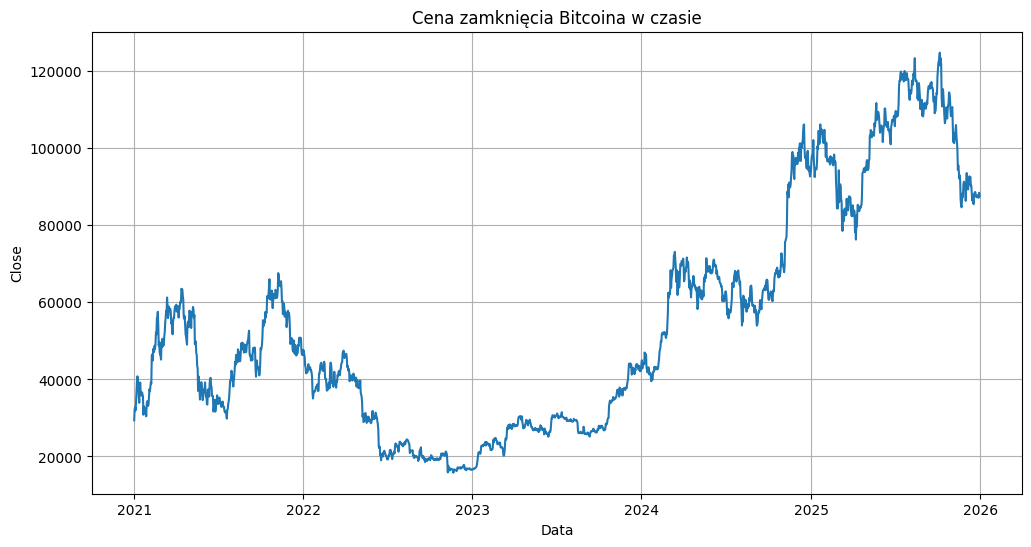

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(btc["Date"], btc["Close"])
plt.title("Cena zamknięcia Bitcoina w czasie")
plt.xlabel("Data")
plt.ylabel("Close")
plt.grid(True)
plt.show()

# Wniosek:
Na podstawie wykresu ceny zamknięcia Bitcoina w latach 2021–2025 widać, że rynek charakteryzuje się dużą zmiennością i wyraźnymi fazami wzrostów oraz spadków. Po silnym spadku w latach 2021–2022 kurs od 2023 roku wszedł w trend wzrostowy, osiągając najwyższe poziomy w 2025 roku, a następnie pojawiła się korekta. Oznacza to, że dane rynkowe Bitcoina dobrze nadają się do dalszej analizy trendu i zmienności.

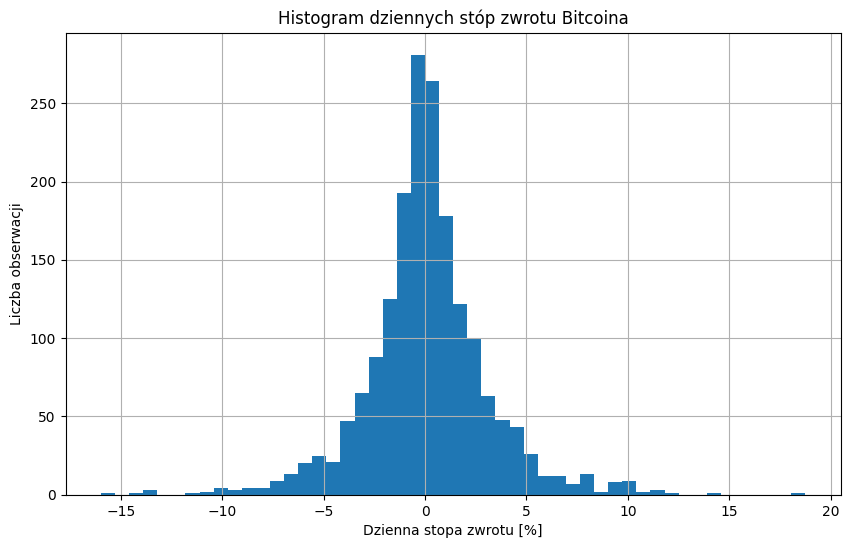

In [16]:
plt.figure(figsize=(10, 6))
btc["Return"].dropna().hist(bins=50)
plt.title("Histogram dziennych stóp zwrotu Bitcoina")
plt.xlabel("Dzienna stopa zwrotu [%]")
plt.ylabel("Liczba obserwacji")
plt.grid(True)
plt.show()

# Wniosek:
Histogram dziennych stóp zwrotu pokazuje, że większość zmian ceny Bitcoina koncentruje się wokół niewielkich wartości, ale występują także obserwacje skrajne, co potwierdza wysoką zmienność rynku kryptowalut.

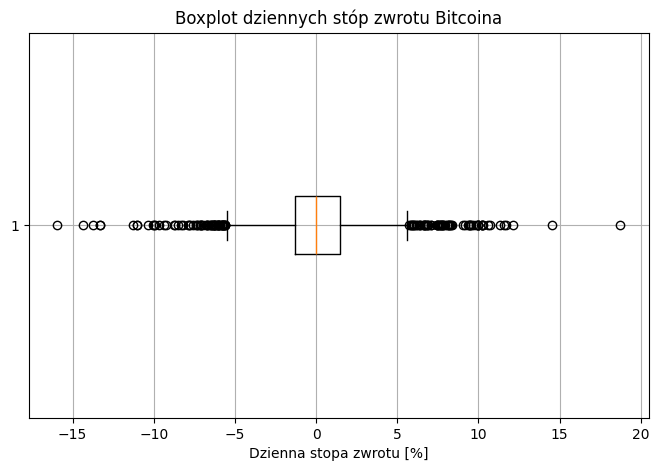

In [17]:
plt.figure(figsize=(8, 5))
plt.boxplot(btc["Return"].dropna(), vert=False)
plt.title("Boxplot dziennych stóp zwrotu Bitcoina")
plt.xlabel("Dzienna stopa zwrotu [%]")
plt.grid(True)
plt.show()

# Wniosek:
Na wykresie pudełkowym widoczne są liczne wartości odstające, co oznacza, że Bitcoin charakteryzuje się częstym występowaniem bardzo silnych dziennych ruchów cenowych.

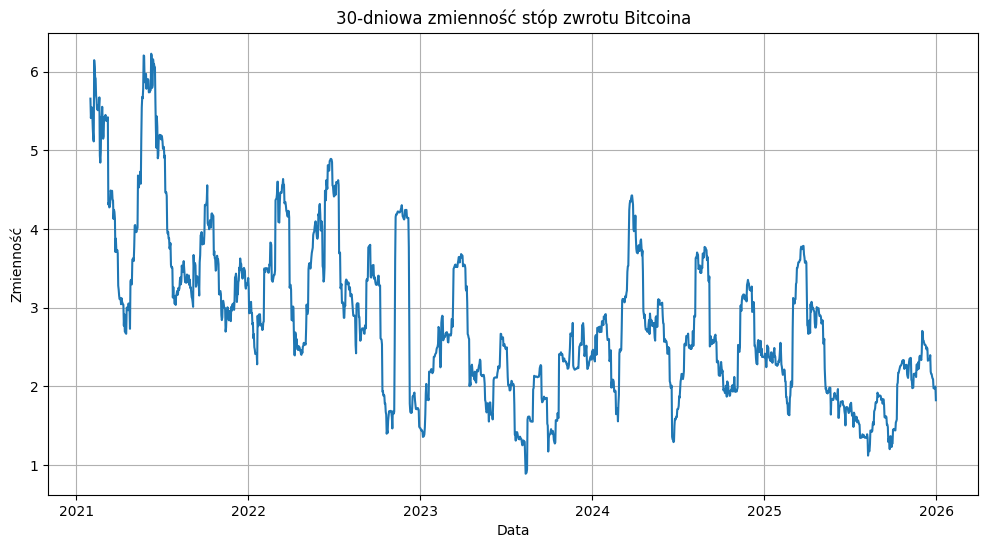

In [18]:
# Chcem przedstawic zmiennosc w czasie dlatego oblicze zmienność ceny BTC za ostatnie 30 dni oraz stworze nową kolumnę
btc["Volatility_30"] = btc["Return"].rolling(window=30).std()
btc[["Date", "Return", "Volatility_30"]].head()
# Dalej przedstawie to na wykresie
plt.figure(figsize=(12, 6))
plt.plot(btc["Date"], btc["Volatility_30"])
plt.title("30-dniowa zmienność stóp zwrotu Bitcoina")
plt.xlabel("Data")
plt.ylabel("Zmienność")
plt.grid(True)
plt.show()

# Wniosek:
30-dniowa zmienność pokazuje, że rynek Bitcoina przechodzi przez okresy spokojniejsze i bardziej turbulentne. W momentach silnych wzrostów i spadków zmienność wyraźnie rośnie.

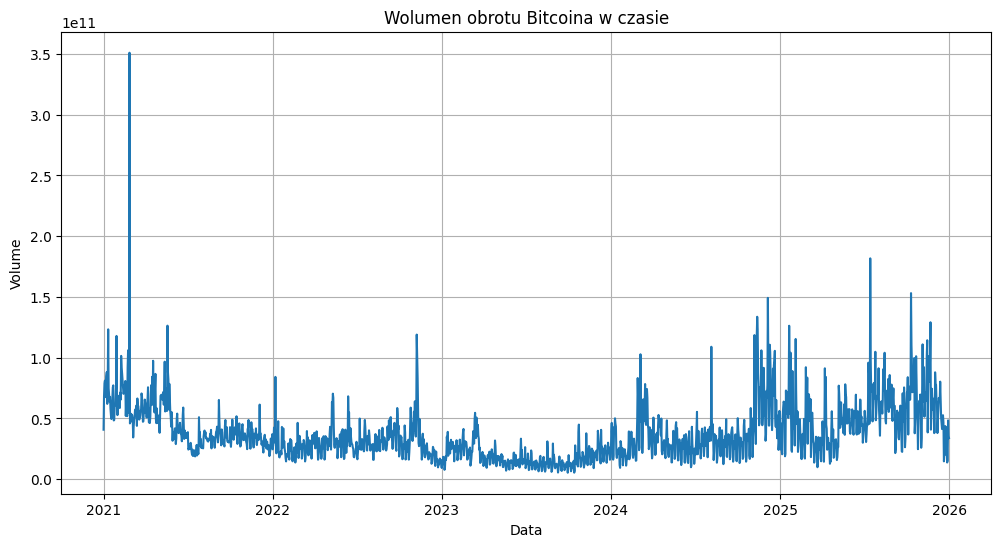

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(btc["Date"], btc["Volume"])
plt.title("Wolumen obrotu Bitcoina w czasie")
plt.xlabel("Data")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

# Wniosek:
Wolumen obrotu zmienia się w czasie i może odzwierciedlać okresy zwiększonej aktywności inwestorów. Szczególnie interesujące są momenty, w których wysoki wolumen współwystępuje z silnymi ruchami cenowymi.

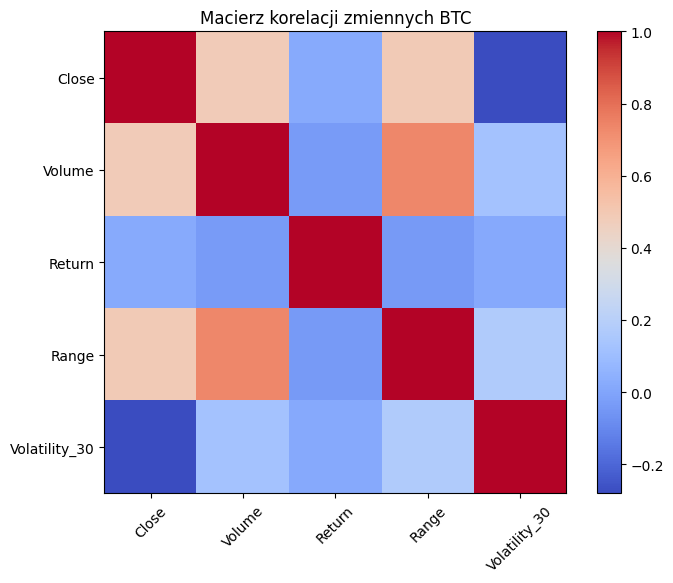

In [20]:
# Korelacja podstawowych zmiennych BTC
btc_corr = btc[["Close", "Volume", "Return", "Range", "Volatility_30"]].corr()
btc_corr

plt.figure(figsize=(8, 6))
plt.imshow(btc_corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(btc_corr.columns)), btc_corr.columns, rotation=45)
plt.yticks(range(len(btc_corr.columns)), btc_corr.columns)
plt.title("Macierz korelacji zmiennych BTC")
plt.show()

# Wniosek:
Macierz korelacji pozwala ocenić siłę zależności między podstawowymi zmiennymi opisującymi rynek Bitcoina. Szczególnie istotne są relacje pomiędzy stopą zwrotu, zakresem wahań i zmiennością.

# Wnioski końcowe:
Przeprowadzona eksploracyjna analiza danych Bitcoina pokazuje, że rynek ten charakteryzuje się wysoką zmiennością, obecnością silnych dziennych wzrostów i spadków oraz zmienną aktywnością mierzoną wolumenem obrotu. Widoczne są zarówno długookresowe trendy cenowe, jak i krótkookresowe gwałtowne ruchy. Otrzymane wyniki stanowią dobrą podstawę do dalszej analizy zależności między zachowaniem rynku BTC a publikowanymi newsami i ich sentymentem.

# Pobieranie newsów

In [21]:
import requests

In [ ]:
# # Pobranie newsów
# API_KEY = "R1Z68LQLHNT9IY4T"

# url = "https://www.alphavantage.co/query"

# params = {
#     "function": "NEWS_SENTIMENT",
#     "tickers": "CRYPTO:BTC",
#     "time_from": "20260328T0000",
#     "time_to": "20260330T2359",
#     "sort": "EARLIEST",
#     "limit": 1000,
#     "apikey": API_KEY
# }

# response = requests.get(url, params=params, timeout=30)
# data = response.json()

# feed = data.get("feed", [])
# print("Liczba newsów:", len(feed))


Liczba newsów: 76


# Data frame

In [23]:
rows = []

for item in feed:
    rows.append({
        "time_published": item.get("time_published"),
        "title": item.get("title"),
        "summary": item.get("summary"),
        "source": item.get("source"),
        "url": item.get("url"),
        "overall_sentiment_score": item.get("overall_sentiment_score"),
        "overall_sentiment_label": item.get("overall_sentiment_label")
    })

news = pd.DataFrame(rows)
news.head()

,time_published,title,summary,source,url,overall_sentiment_score,overall_sentiment_label
0,20260328T000616,Morgan Stanley Sets Bitcoin ETF Fee at Ultra-L...,Bloomberg ETF analyst Eric Balchunas said Morg...,Cointelegraph,https://cointelegraph.com/news/morgan-stanley-...,0.130618,Neutral
1,20260328T030412,"Stablecoins Will Be Crypto's ""ChatGPT Moment,""...",Ripple's Brad Garlinghouse noted that stableco...,Cointelegraph,https://cointelegraph.com/news/stablecoins-wil...,0.262551,Somewhat-Bullish
2,20260328T073021,Spot Bitcoin ETFs Break 4-Week Inflow Streak w...,Spot Bitcoin ETFs see $296 million in weekly o...,Cointelegraph,https://cointelegraph.com/news/bitcoin-etfs-br...,-0.078851,Neutral
3,20260328T080000,What's the Better Buy to Save for Retirement: ...,These two assets don't need to be mutually exc...,Motley Fool,https://www.fool.com/investing/2026/03/28/what...,0.142941,Neutral
4,20260328T080000,Bitcoin Recovery Time Extends If Selloff Deepe...,Bitcoin's return to an all-time high depends o...,Cointelegraph,https://cointelegraph.com/markets/potential-bi...,0.021941,Neutral


In [24]:
news.shape

(76, 7)

In [25]:
news.info()

<class 'pandas.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   time_published           76 non-null     str    
 1   title                    76 non-null     str    
 2   summary                  76 non-null     str    
 3   source                   76 non-null     str    
 4   url                      76 non-null     str    
 5   overall_sentiment_score  76 non-null     float64
 6   overall_sentiment_label  76 non-null     str    
dtypes: float64(1), str(6)
memory usage: 4.3 KB


In [26]:
news.isnull().sum()

time_published             0
title                      0
summary                    0
source                     0
url                        0
overall_sentiment_score    0
overall_sentiment_label    0
dtype: int64

In [27]:
# Czyszczenie daty
news["time_published"] = pd.to_datetime(
    news["time_published"],
    format="%Y%m%dT%H%M%S",
    errors="coerce"
)

news["date"] = news["time_published"].dt.date

news = news.drop_duplicates()
news = news.dropna(subset=["time_published", "title", "source"])

news.head()

,time_published,title,summary,source,url,overall_sentiment_score,overall_sentiment_label,date
0,2026-03-28 00:06:16,Morgan Stanley Sets Bitcoin ETF Fee at Ultra-L...,Bloomberg ETF analyst Eric Balchunas said Morg...,Cointelegraph,https://cointelegraph.com/news/morgan-stanley-...,0.130618,Neutral,2026-03-28
1,2026-03-28 03:04:12,"Stablecoins Will Be Crypto's ""ChatGPT Moment,""...",Ripple's Brad Garlinghouse noted that stableco...,Cointelegraph,https://cointelegraph.com/news/stablecoins-wil...,0.262551,Somewhat-Bullish,2026-03-28
2,2026-03-28 07:30:21,Spot Bitcoin ETFs Break 4-Week Inflow Streak w...,Spot Bitcoin ETFs see $296 million in weekly o...,Cointelegraph,https://cointelegraph.com/news/bitcoin-etfs-br...,-0.078851,Neutral,2026-03-28
3,2026-03-28 08:00:00,What's the Better Buy to Save for Retirement: ...,These two assets don't need to be mutually exc...,Motley Fool,https://www.fool.com/investing/2026/03/28/what...,0.142941,Neutral,2026-03-28
4,2026-03-28 08:00:00,Bitcoin Recovery Time Extends If Selloff Deepe...,Bitcoin's return to an all-time high depends o...,Cointelegraph,https://cointelegraph.com/markets/potential-bi...,0.021941,Neutral,2026-03-28


In [28]:
# Kolejność
news = news[
    [
        "date",
        "time_published",
        "title",
        "summary",
        "source",
        "url",
        "overall_sentiment_score",
        "overall_sentiment_label"
    ]
]

news.head()

,date,time_published,title,summary,source,url,overall_sentiment_score,overall_sentiment_label
0,2026-03-28,2026-03-28 00:06:16,Morgan Stanley Sets Bitcoin ETF Fee at Ultra-L...,Bloomberg ETF analyst Eric Balchunas said Morg...,Cointelegraph,https://cointelegraph.com/news/morgan-stanley-...,0.130618,Neutral
1,2026-03-28,2026-03-28 03:04:12,"Stablecoins Will Be Crypto's ""ChatGPT Moment,""...",Ripple's Brad Garlinghouse noted that stableco...,Cointelegraph,https://cointelegraph.com/news/stablecoins-wil...,0.262551,Somewhat-Bullish
2,2026-03-28,2026-03-28 07:30:21,Spot Bitcoin ETFs Break 4-Week Inflow Streak w...,Spot Bitcoin ETFs see $296 million in weekly o...,Cointelegraph,https://cointelegraph.com/news/bitcoin-etfs-br...,-0.078851,Neutral
3,2026-03-28,2026-03-28 08:00:00,What's the Better Buy to Save for Retirement: ...,These two assets don't need to be mutually exc...,Motley Fool,https://www.fool.com/investing/2026/03/28/what...,0.142941,Neutral
4,2026-03-28,2026-03-28 08:00:00,Bitcoin Recovery Time Extends If Selloff Deepe...,Bitcoin's return to an all-time high depends o...,Cointelegraph,https://cointelegraph.com/markets/potential-bi...,0.021941,Neutral


In [29]:
news.to_csv("btc_news.csv", index=False, encoding="utf-8-sig")
print("Zapisano btc_news.csv")

Zapisano btc_news.csv


# EDA newsów
## Podstawowe informacje

In [30]:
news.shape

(76, 8)

In [31]:
news.info()

<class 'pandas.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     76 non-null     object        
 1   time_published           76 non-null     datetime64[us]
 2   title                    76 non-null     str           
 3   summary                  76 non-null     str           
 4   source                   76 non-null     str           
 5   url                      76 non-null     str           
 6   overall_sentiment_score  76 non-null     float64       
 7   overall_sentiment_label  76 non-null     str           
dtypes: datetime64[us](1), float64(1), object(1), str(5)
memory usage: 4.9+ KB


In [32]:
news.isnull().sum()

date                       0
time_published             0
title                      0
summary                    0
source                     0
url                        0
overall_sentiment_score    0
overall_sentiment_label    0
dtype: int64

In [33]:
news["date"].min(), news["date"].max()

(datetime.date(2026, 3, 28), datetime.date(2026, 3, 30))

In [34]:
news["source"].nunique()

7

# BTC w ustalonym okresie
Dla prowadzenia prawidłowej EDA trzeba brać dane po BTC z tego samego okresu co i newsy

In [35]:
btc_hourly = yf.download("BTC-USD", start="2026-03-28", end="2026-03-31", interval="1h")
btc_hourly = btc_hourly.reset_index()

btc_hourly.columns = ["Datetime", "Close", "High", "Low", "Open", "Volume"]

btc_hourly["Return"] = btc_hourly["Close"].pct_change() * 100
btc_hourly["Range"] = btc_hourly["High"] - btc_hourly["Low"]
btc_hourly["hour"] = pd.to_datetime(btc_hourly["Datetime"], utc=True).dt.floor("h").dt.tz_localize(None)

news["hour"] = pd.to_datetime(news["time_published"]).dt.floor("h")
news["hour"] = news["hour"].dt.tz_localize(None)

news_hourly = news.groupby("hour").agg(
    news_count=("title", "count"),
    avg_sentiment=("overall_sentiment_score", "mean"),
    source_count=("source", "nunique")
).reset_index()

merged_hourly = pd.merge(
    btc_hourly,
    news_hourly,
    on="hour",
    how="left"
)

merged_hourly["news_count"] = merged_hourly["news_count"].fillna(0)
merged_hourly["avg_sentiment"] = merged_hourly["avg_sentiment"].fillna(0)
merged_hourly["source_count"] = merged_hourly["source_count"].fillna(0)

merged_hourly.head()

[*********************100%***********************]  1 of 1 completed


,Datetime,Close,High,Low,Open,Volume,Return,Range,hour,news_count,avg_sentiment,source_count
0,2026-03-28 00:00:00+00:00,66376.828125,66468.921875,66252.890625,66363.414062,0,NaN,216.031250,2026-03-28 00:00:00,1.0,0.130618,1.0
1,2026-03-28 01:00:00+00:00,66063.234375,66379.742188,66027.359375,66379.742188,0,-0.472445,352.382812,2026-03-28 01:00:00,0.0,0.000000,0.0
2,2026-03-28 02:00:00+00:00,66000.335938,66205.796875,65916.359375,66125.562500,0,-0.095209,289.437500,2026-03-28 02:00:00,0.0,0.000000,0.0
3,2026-03-28 03:00:00+00:00,66167.835938,66190.742188,66004.312500,66004.312500,0,0.253787,186.429688,2026-03-28 03:00:00,1.0,0.262551,1.0
4,2026-03-28 04:00:00+00:00,66190.468750,66254.578125,66091.335938,66184.312500,0,0.034205,163.242188,2026-03-28 04:00:00,0.0,0.000000,0.0


In [36]:
merged_hourly.shape


(70, 12)

In [37]:
merged_hourly[["hour", "Close", "Return", "Range", "news_count", "avg_sentiment", "source_count"]].head(10)

,hour,Close,Return,Range,news_count,avg_sentiment,source_count
0,2026-03-28 00:00:00,66376.828125,NaN,216.031250,1.0,0.130618,1.0
1,2026-03-28 01:00:00,66063.234375,-0.472445,352.382812,0.0,0.000000,0.0
2,2026-03-28 02:00:00,66000.335938,-0.095209,289.437500,0.0,0.000000,0.0
3,2026-03-28 03:00:00,66167.835938,0.253787,186.429688,1.0,0.262551,1.0
4,2026-03-28 04:00:00,66190.468750,0.034205,163.242188,0.0,0.000000,0.0
5,2026-03-28 05:00:00,66309.601562,0.179985,147.679688,0.0,0.000000,0.0
6,2026-03-28 06:00:00,66365.632812,0.084499,178.765625,0.0,0.000000,0.0
7,2026-03-28 07:00:00,66508.242188,0.214884,151.437500,1.0,-0.078851,1.0
8,2026-03-28 08:00:00,66355.976562,-0.228942,157.000000,2.0,0.082441,2.0
9,2026-03-28 09:00:00,66266.054688,-0.135514,143.125000,1.0,0.172907,1.0


In [38]:
merged_hourly[["news_count", "avg_sentiment", "source_count"]].describe()


,news_count,avg_sentiment,source_count
count,70.000000,70.000000,70.000000
mean,1.085714,0.053690,0.871429
std,1.471890,0.098161,1.062148
min,0.000000,-0.096481,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000
75%,1.000000,0.099899,1.000000
max,6.000000,0.440908,4.000000


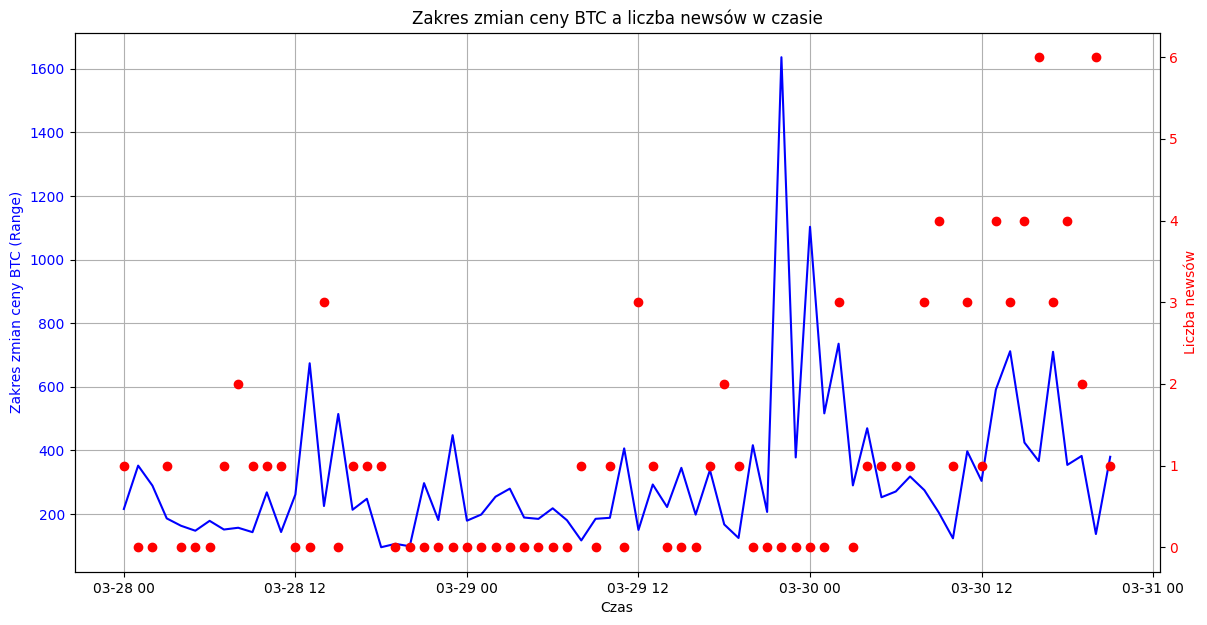

In [52]:
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.plot(
    merged_hourly["hour"],
    merged_hourly["Range"],
    color="blue",
    label="Range BTC"
)
ax1.set_xlabel("Czas")
ax1.set_ylabel("Zakres zmian ceny BTC (Range)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.scatter(
    merged_hourly["hour"],
    merged_hourly["news_count"],
    color="red",
    label="Liczba newsów"
)
ax2.set_ylabel("Liczba newsów", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Zakres zmian ceny BTC a liczba newsów w czasie")
plt.show()

# Wniosek:
Na wykresie można zauważyć, że okresy większej aktywności newsowej częściej współwystępowały z podwyższonym zakresem zmian ceny BTC, szczególnie w bardziej dynamicznej części analizowanego przedziału czasu. Sugeruje to, że większa liczba publikacji mogła być związana z silniejszym ruchem rynku i większą zmiennością Bitcoina. Jednocześnie zależność ta nie ma całkowicie regularnego charakteru, dlatego sam wykres należy traktować jako wizualną przesłankę, którą warto uzupełnić analizą korelacji między Range a news_count.

# Test korelacji (Spearmana)

In [ ]:
#Czy większa liczba newsów współwystępuje z większym zakresem zmian ceny BTC w tym samym przedziale czasowym?
from scipy.stats import spearmanr

corr_data_range = merged_hourly[["Range", "news_count"]].dropna()

rho_range, p_value_range = spearmanr(
    corr_data_range["Range"],
    corr_data_range["news_count"]
)

print("Spearman rho:", rho_range)
print("p-value:", p_value_range)

Spearman rho: 0.05187685545979208
p-value: 0.6697397316028132


# Wniosek:
W analizowanym zbiorze nie stwierdzono wyraźnej zależności między zakresem zmian ceny BTC (Range) a liczbą newsów (news_count). Otrzymany współczynnik korelacji jest bardzo bliski zeru, co sugeruje brak istotnego związku między intensywnością publikacji a skalą godzinowych wahań ceny Bitcoina. Dodatkowo wynik testu nie był istotny statystycznie, dlatego nie ma podstaw do potwierdzenia, że większa liczba newsów współwystępowała z większą zmiennością rynku w badanym okresie.

## Positive news

In [40]:
positive_news = news[news["overall_sentiment_score"] > 0].copy()

positive_hourly = positive_news.groupby("hour").agg(
    positive_news_count=("title", "count"),
    avg_positive_sentiment=("overall_sentiment_score", "mean")
).reset_index()

all_news_hourly = news.groupby("hour").agg(
    news_count=("title", "count")
).reset_index()

btc_positive_table = pd.merge(
    btc_hourly[["hour", "Close", "Return", "Range", "Volume"]],
    all_news_hourly,
    on="hour",
    how="left"
)

btc_positive_table = pd.merge(
    btc_positive_table,
    positive_hourly,
    on="hour",
    how="left"
)

btc_positive_table["news_count"] = btc_positive_table["news_count"].fillna(0)
btc_positive_table["positive_news_count"] = btc_positive_table["positive_news_count"].fillna(0)
btc_positive_table["avg_positive_sentiment"] = btc_positive_table["avg_positive_sentiment"].fillna(0)

btc_positive_table["positive_share"] = np.where(
    btc_positive_table["news_count"] > 0,
    btc_positive_table["positive_news_count"] / btc_positive_table["news_count"],
    0
)

btc_positive_table.head(20)

,hour,Close,Return,Range,Volume,news_count,positive_news_count,avg_positive_sentiment,positive_share
0,2026-03-28 00:00:00,66376.828125,NaN,216.031250,0,1.0,1.0,0.130618,1.000000
1,2026-03-28 01:00:00,66063.234375,-0.472445,352.382812,0,0.0,0.0,0.000000,0.000000
2,2026-03-28 02:00:00,66000.335938,-0.095209,289.437500,0,0.0,0.0,0.000000,0.000000
3,2026-03-28 03:00:00,66167.835938,0.253787,186.429688,0,1.0,1.0,0.262551,1.000000
4,2026-03-28 04:00:00,66190.468750,0.034205,163.242188,0,0.0,0.0,0.000000,0.000000
5,2026-03-28 05:00:00,66309.601562,0.179985,147.679688,0,0.0,0.0,0.000000,0.000000
6,2026-03-28 06:00:00,66365.632812,0.084499,178.765625,0,0.0,0.0,0.000000,0.000000
7,2026-03-28 07:00:00,66508.242188,0.214884,151.437500,0,1.0,0.0,0.000000,0.000000
8,2026-03-28 08:00:00,66355.976562,-0.228942,157.000000,0,2.0,2.0,0.082441,1.000000
9,2026-03-28 09:00:00,66266.054688,-0.135514,143.125000,0,1.0,1.0,0.172907,1.000000


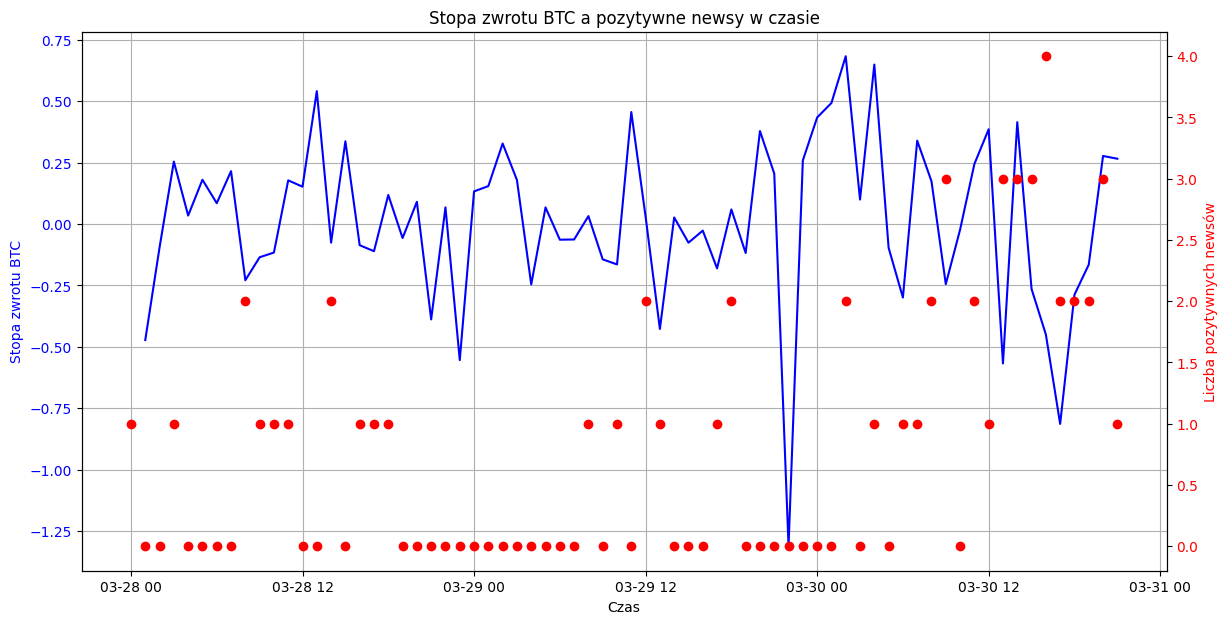

In [50]:
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.plot(
    btc_positive_table["hour"],
    btc_positive_table["Return"],
    color="blue",
    label="Return BTC"
)
ax1.set_xlabel("Czas")
ax1.set_ylabel("Stopa zwrotu BTC", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.scatter(
    btc_positive_table["hour"],
    btc_positive_table["positive_news_count"],
    color="red",
    label="Pozytywne newsy"
)
ax2.set_ylabel("Liczba pozytywnych newsów", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Stopa zwrotu BTC a pozytywne newsy w czasie")
plt.show()

# Wniosek: 
W badanym okresie nie widać wyraźnego i trwałego wzorca, zgodnie z którym większa liczba pozytywnych newsów współwystępowałaby z bardziej dodatnią stopą zwrotu BTC. Pozytywne publikacje pojawiały się zarówno w godzinach wzrostów, jak i spadków, co sugeruje, że sama liczba pozytywnych newsów nie dawała jednoznacznego sygnału co do krótkookresowego kierunku zmian rynku. Wizualizacja jest więc zgodna z wynikiem testu statystycznego, który nie potwierdził istotnej zależności między liczbą pozytywnych newsów a wzrostem ceny BTC.

# Test korelacji (Spearmana)

In [ ]:
#czy więcej pozytywnych newsów współwystępuje ze wzrostem ceny?
from scipy.stats import spearmanr

corr_data_pos_return = btc_positive_table[["Return", "positive_news_count"]].dropna()

rho_pos_return, p_value_pos_return = spearmanr(
    corr_data_pos_return["Return"],
    corr_data_pos_return["positive_news_count"]
)

print("Spearman rho:", rho_pos_return)
print("p-value:", p_value_pos_return)

Spearman rho: -0.17480348453400837
p-value: 0.15083540918023491


# Wniosek:
W analizowanym zbiorze zaobserwowano słabą ujemną zależność między godzinową stopą zwrotu BTC a liczbą pozytywnych newsów. Oznacza to, że większa liczba pozytywnych publikacji nie współwystępowała wyraźnie z bardziej dodatnimi zmianami ceny Bitcoina. Jednocześnie wynik testu nie był istotny statystycznie, dlatego nie ma podstaw do potwierdzenia istnienia wyraźnej zależności między liczbą pozytywnych newsów a wzrostem ceny BTC w badanym okresie.

# Negative news

In [43]:
negative_news = news[news["overall_sentiment_score"] < 0].copy()

negative_hourly = negative_news.groupby("hour").agg(
    negative_news_count=("title", "count"),
    avg_negative_sentiment=("overall_sentiment_score", "mean")
).reset_index()

all_news_hourly = news.groupby("hour").agg(
    news_count=("title", "count")
).reset_index()

btc_negative_table = pd.merge(
    btc_hourly[["hour", "Close", "Return", "Range", "Volume"]],
    all_news_hourly,
    on="hour",
    how="left"
)

btc_negative_table = pd.merge(
    btc_negative_table,
    negative_hourly,
    on="hour",
    how="left"
)

btc_negative_table["news_count"] = btc_negative_table["news_count"].fillna(0)
btc_negative_table["negative_news_count"] = btc_negative_table["negative_news_count"].fillna(0)
btc_negative_table["avg_negative_sentiment"] = btc_negative_table["avg_negative_sentiment"].fillna(0)

btc_negative_table["negative_share"] = np.where(
    btc_negative_table["news_count"] > 0,
    btc_negative_table["negative_news_count"] / btc_negative_table["news_count"],
    0
)

btc_negative_table.head(20)

,hour,Close,Return,Range,Volume,news_count,negative_news_count,avg_negative_sentiment,negative_share
0,2026-03-28 00:00:00,66376.828125,NaN,216.031250,0,1.0,0.0,0.000000,0.000000
1,2026-03-28 01:00:00,66063.234375,-0.472445,352.382812,0,0.0,0.0,0.000000,0.000000
2,2026-03-28 02:00:00,66000.335938,-0.095209,289.437500,0,0.0,0.0,0.000000,0.000000
3,2026-03-28 03:00:00,66167.835938,0.253787,186.429688,0,1.0,0.0,0.000000,0.000000
4,2026-03-28 04:00:00,66190.468750,0.034205,163.242188,0,0.0,0.0,0.000000,0.000000
5,2026-03-28 05:00:00,66309.601562,0.179985,147.679688,0,0.0,0.0,0.000000,0.000000
6,2026-03-28 06:00:00,66365.632812,0.084499,178.765625,0,0.0,0.0,0.000000,0.000000
7,2026-03-28 07:00:00,66508.242188,0.214884,151.437500,0,1.0,1.0,-0.078851,1.000000
8,2026-03-28 08:00:00,66355.976562,-0.228942,157.000000,0,2.0,0.0,0.000000,0.000000
9,2026-03-28 09:00:00,66266.054688,-0.135514,143.125000,0,1.0,0.0,0.000000,0.000000


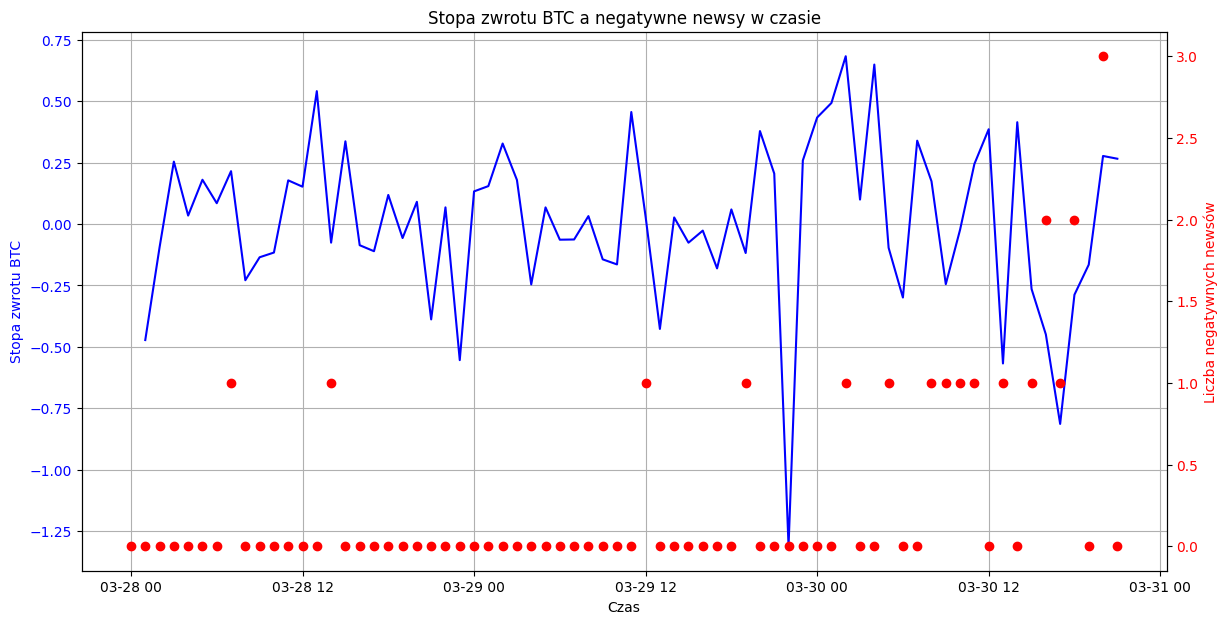

In [51]:
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.plot(
    btc_negative_table["hour"],
    btc_negative_table["Return"],
    color="blue",
    label="Return BTC"
)
ax1.set_xlabel("Czas")
ax1.set_ylabel("Stopa zwrotu BTC", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.scatter(
    btc_negative_table["hour"],
    btc_negative_table["negative_news_count"],
    color="red",
    label="Negatywne newsy"
)
ax2.set_ylabel("Liczba negatywnych newsów", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Stopa zwrotu BTC a negatywne newsy w czasie")
plt.show()

# Wniosek:
W przypadku negatywnych newsów można zauważyć, że część ich publikacji pojawiała się w godzinach słabszego zachowania rynku i bardziej ujemnych stóp zwrotu BTC, jednak zależność ta nie jest na wykresie jednoznaczna i regularna. Negatywne publikacje nie występowały wyłącznie przy spadkach, lecz także w momentach neutralnych lub mieszanych zmian ceny. Oznacza to, że wizualnie można dostrzec pewien kierunek zgodny z intuicją, ale sam wykres nie daje podstaw do stwierdzenia wyraźnej i silnej zależności.

# Test korelacji

In [ ]:
#czy więcej negatywnych newsów współwystępuje z bardziej ujemną zmianą ceny?
from scipy.stats import spearmanr

corr_data_neg_return = btc_negative_table[["Return", "negative_news_count"]].dropna()

rho_neg_return, p_value_neg_return = spearmanr(
    corr_data_neg_return["Return"],
    corr_data_neg_return["negative_news_count"]
)

print("Spearman rho:", rho_neg_return)
print("p-value:", p_value_neg_return)

Spearman rho: -0.17597373645328473
p-value: 0.14807712331669953


# Wniosek: 
W analizowanym zbiorze zaobserwowano ujemną zależność między godzinową stopą zwrotu BTC a liczbą negatywnych newsów, co sugeruje, że większa liczba negatywnych publikacji częściej współwystępowała ze słabszym zachowaniem rynku lub bardziej ujemnymi zmianami ceny. Jednocześnie wynik testu nie okazał się istotny statystycznie, dlatego nie ma podstaw, aby uznać tę zależność za wyraźnie potwierdzoną w badanym okresie. Oznacza to, że obserwowany związek może mieć charakter przypadkowy lub być zbyt słaby, aby formułować mocniejsze wnioski.

# Wniosek ogólny:
Porównanie godzinowej stopy zwrotu BTC z liczbą pozytywnych i negatywnych newsów pokazuje, że aktywność informacyjna współwystępowała z bieżącymi zmianami rynku, ale nie tworzyła prostego i jednoznacznego wzorca. W szczególności pozytywne newsy nie były wyraźnie związane z dodatnimi stopami zwrotu, natomiast dla negatywnych newsów można zauważyć kierunek bardziej zgodny z intuicją, choć nadal niewystarczająco wyraźny, by mówić o silnej zależności na podstawie samej wizualizacji.
